In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
class TwoLayersPerceptron:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size, )    # Input to hidden
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size)   # Hidden to output
        self.b2 = np.zeros((1, output_size))
        self.errores = []

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_deriv(self, x):
        return x * (1 - x)

    def predict(self, X):
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self._sigmoid(z1)
        return np.dot(a1, self.W2) + self.b2

    def fit(self, X, y, learning_rate=0.01, epochs=100):
        self.errores = []
        with tqdm(range(epochs), desc="epoch") as pbar:
            for _ in pbar:
                # Forward pass
                z1 = np.dot(X, self.W1) + self.b1
                a1 = self._sigmoid(z1)
                output = np.dot(a1, self.W2) + self.b2

                error = y - output
                mse = np.mean(error ** 2)
                self.errores.append(mse)

                pbar.set_postfix({"loss" : f"{mse}"})

                # Backward pass
                d_output = error
                error_hidden = d_output.dot(self.W2.T)
                d_hidden = error_hidden * self._sigmoid_deriv(a1)

                # Update weights and biases
                n = len(X)
                self.W2 += (a1.T.dot(d_output) / n) * learning_rate
                self.b2 += (np.sum(d_output, axis=0, keepdims=True) / n) * learning_rate
                self.W1 += (X.T.dot(d_hidden) / n) * learning_rate
                self.b1 += (np.sum(d_hidden, axis=0, keepdims=True) / n) * learning_rate

In [3]:
df = pd.read_parquet("../data/data_train.parquet")
np.random.seed(42)

X = df[['X']].values
y = df[['Y']].values

model = TwoLayersPerceptron(X.shape[1], 50, y.shape[1])
model.fit(X, y, learning_rate=0.2, epochs=5000)

epoch: 100%|██████████| 5000/5000 [00:03<00:00, 1459.28it/s, loss=0.0003289314578434674] 


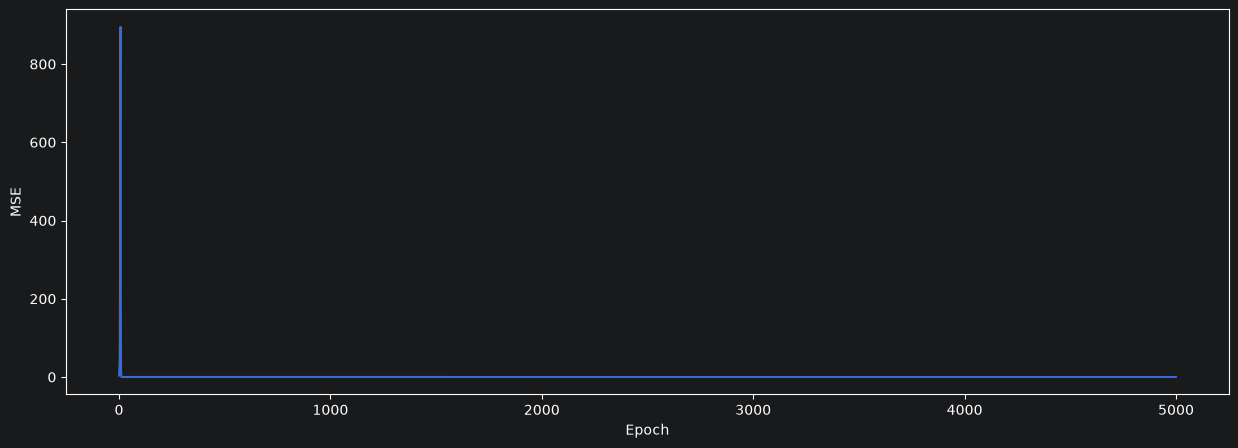

In [4]:
plt.figure(figsize=(15, 5))
plt.plot(model.errores)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

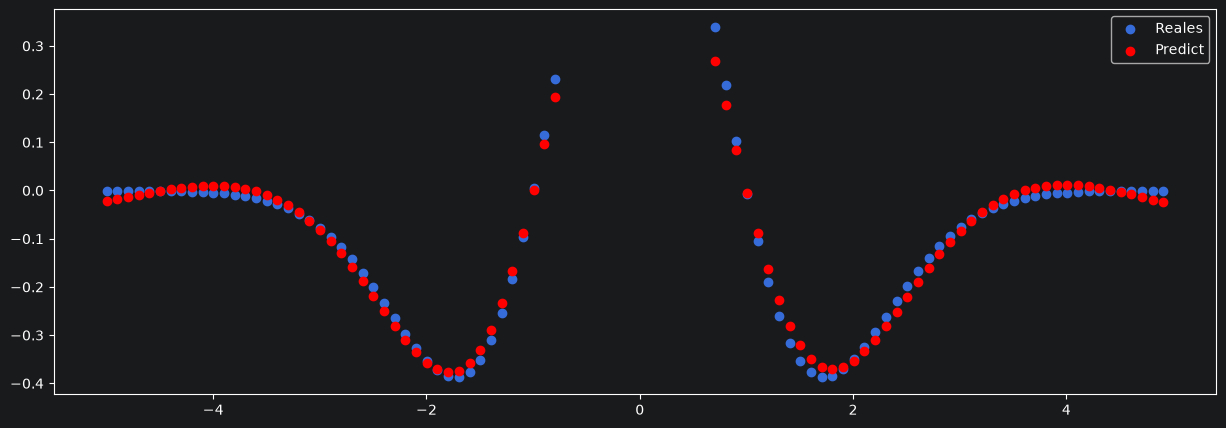

In [5]:
plt.figure(figsize=(15, 5))
plt.scatter(X, y, label="Reales")
plt.scatter(X, model.predict(X), label="Predict", color="r")
plt.legend()
plt.show()